파이썬 증권 데이터 분석 - 김황후 (한빛미디어)

# 3. 판다스를 활용한 데이터 분석

## 3.1 Numpy

In [3]:
#배열생성
import numpy as np

a = np.array([[1,2], [3,4]])
a

array([[1, 2],
       [3, 4]])

In [4]:
a.shape

(2, 2)

In [9]:
#인덱싱. 행렬이라고 생각하면 됨
print(a[0][1])
print(a[0,1])

2
2


In [10]:
#transpose
a.T

array([[1, 3],
       [2, 4]])

In [11]:
#평탄화. 모든 원소를 그냥 하나의 리스트로 넣어주는 것
a.flatten()

array([1, 2, 3, 4])

In [16]:
#덧셈 연산
print(a+a)

#뺄셈연산
print(a-a)

#단순 곱 연산
print(a*a)

#단순 나눗셈 연산
print(a/a)

#행렬곱 연산
print(a.dot(a))

[[2 4]
 [6 8]]
[[0 0]
 [0 0]]
[[ 1  4]
 [ 9 16]]
[[1. 1.]
 [1. 1.]]
[[ 7 10]
 [15 22]]


#### broadcasting

이 경우 일부러 곱해주기 위해 b를 복제해서 각 행에 곱해줬다.

In [22]:

#넘파이의 경우, 행렬 연산에서 크기가 맞지 않을 경우에 없는 것을 복제해서 계산해준다.
a = np.array([[1,2], [3,4]]) #2x2
b = np.array([10,100]) #1x2

print(a*b)

[[ 10 200]
 [ 30 400]]


#### 내적(dot product)

In [28]:
#특이하게 넘파이는 1차원 배열 또한 행렬곱을 진행해준다. 
#처음에 나오는 배열을 행 벡터로 인식하고, 뒤에 오는 배열을 열 벡터로 인식한다.
b.dot(b)

10100

In [32]:
c = np.array([[1,2,3],[4,5,6]])
d = np.array([[7,8],[9,10], [11,12]])

In [34]:
print(c.shape)
print(d.shape)

(2, 3)
(3, 2)


In [39]:
print(c.dot(d))
print(d.dot(c))

[[ 58  64]
 [139 154]]
[[ 39  54  69]
 [ 49  68  87]
 [ 59  82 105]]


In [41]:
#평소의 행렬곱처럼 차원이 맞지 않으면 행렬곱을 진행할 수 없다.
print(c.dot(d.T))

ValueError: shapes (2,3) and (2,3) not aligned: 3 (dim 1) != 2 (dim 0)

## 3.2 Series

In [1]:
import pandas as pd
s = pd.Series([0.0, 3.6, 2.0, 5.8, 4.2, 8.0])
s

0    0.0
1    3.6
2    2.0
3    5.8
4    4.2
5    8.0
dtype: float64

In [2]:
#인덱스를 변경할 수 있다. 
s.index = pd.Index([0.0, 1.2, 1.8, 3.0, 3.6, 4.8])
s.index.name = 'my index'
s

my index
0.0    0.0
1.2    3.6
1.8    2.0
3.0    5.8
3.6    4.2
4.8    8.0
dtype: float64

In [3]:
#시리즈 명도 설정할 수 있다고 한다~
s.name = 'my series'
s

my index
0.0    0.0
1.2    3.6
1.8    2.0
3.0    5.8
3.6    4.2
4.8    8.0
Name: my series, dtype: float64

In [4]:
#데이터 추가. 인덱스 명과 원하는 값을 넣어주면 된다.

s[5.9] = 5.5
s

my index
0.0    0.0
1.2    3.6
1.8    2.0
3.0    5.8
3.6    4.2
4.8    8.0
5.9    5.5
Name: my series, dtype: float64

In [5]:
import pandas as pd

s = pd.Series([0.0, 3.6, 2.0, 5.8, 4.2, 8.0])

In [6]:
s.index = pd.Index([0.0, 1.2, 1.8, 3.0, 3.6, 4.8])

### 3.2.4 데이터 인덱싱

- 인덱스 추출

In [7]:
#가장 마지막 인덱스를 뽑기

#인덱스 추출은 index로 진행한다.
s.index[-1]

4.8

- 값 추출

In [9]:
# 1) values 메서드로 뽑기
print(s.values[-1])

# 2) iloc 메서드로 뽑기
print(s.iloc[-1])

# 3) loc 메서드로 뽑기 = 이렇게 인덱스 명을 넣어줘야 한다.
print(s.loc[4.8])

8.0
8.0
8.0


- values 와 iloc의 차이점

In [12]:
#values는 array를 반환
s.values[:]

array([0. , 3.6, 2. , 5.8, 4.2, 8. ])

In [13]:
#iloc은 series를 반환
s.iloc[:]

0.0    0.0
1.2    3.6
1.8    2.0
3.0    5.8
3.6    4.2
4.8    8.0
dtype: float64

### 3.2.5 데이터 삭제

In [15]:
#이렇게 인덱스를 넣어주면 된다. 
s.drop(4.8)

0.0    0.0
1.2    3.6
1.8    2.0
3.0    5.8
3.6    4.2
dtype: float64

In [16]:
#하지만 실제 데이터에는 변함이 없다.
s

0.0    0.0
1.2    3.6
1.8    2.0
3.0    5.8
3.6    4.2
4.8    8.0
dtype: float64

### 3.2.6 시리즈 정보 보기

In [17]:
s.describe()

count    6.000000
mean     3.933333
std      2.807609
min      0.000000
25%      2.400000
50%      3.900000
75%      5.400000
max      8.000000
dtype: float64

### 3.2.7 Series 출력

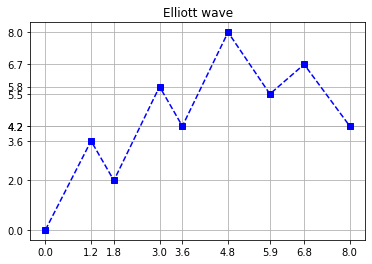

In [23]:
import pandas as pd

#시리즈 만들기
s = pd.Series([0.0, 3.6, 2.0, 5.8, 4.2, 8.0, 5.5, 6.7, 4.2])
s.index = pd.Index([0.0, 1.2, 1.8, 3.0, 3.6, 4.8, 5.9, 6.8, 8.0])

#시리즈 이름 만들기
s.name = "내 시리즈"
s.index.name = "내 인덱스"

import matplotlib.pyplot as plt

plt.title('Elliott wave')
plt.plot(s, 'bs--')
plt.xticks(s.index)
plt.yticks(s.values)
plt.grid(True)
plt.show()


## 3.2 DataFrame

### 3.1.1 딕셔너리를 이용한 생성법

In [1]:
import pandas as pd

df = pd.DataFrame({'KOSPI' : [1915, 1961, 2026, 2467, 2041]
                  ,'KOSDAQ' : [542,682,631,798,675]})

df

,KOSPI,KOSDAQ
0,1915,542
1,1961,682
2,2026,631
3,2467,798
4,2041,675


> 이렇게 칼럼명과 그에 맞는 데이터를 넣어주면 데이터 프레임을 생성할 수 있다.

In [3]:
import pandas as pd

df2 = pd.DataFrame(data = {'KOSPI' : [1915, 1961, 2026, 2467, 2041]
                  ,'KOSDAQ' : [542,682,631,798,675]}
                  ,index = [2014, 2015, 2016, 2017, 2018])

df2

,KOSPI,KOSDAQ
2014,1915,542
2015,1961,682
2016,2026,631
2017,2467,798
2018,2041,675


### 3.3.2 Series를 이용한 DataFrame 생성

In [20]:
kospi = pd.Series([1915, 1961, 2026, 2467, 2041], index = [2014, 2015, 2016, 2017, 2018], name = 'KOSPI')
kospi

2014    1915
2015    1961
2016    2026
2017    2467
2018    2041
Name: KOSPI, dtype: int64

In [21]:
kosdaq = pd.Series([542, 682,631,798,675], index = [2014, 2015, 2016, 2017, 2018], name = 'KOSDAQ')
kosdaq


2014    542
2015    682
2016    631
2017    798
2018    675
Name: KOSDAQ, dtype: int64

In [23]:
#이와 같이 딕셔너리 형태로 넣어줘야 한다고 함
df3 = pd.DataFrame({kospi.name : kospi, kosdaq.name : kosdaq})
df3

,KOSPI,KOSDAQ
2014,1915,542
2015,1961,682
2016,2026,631
2017,2467,798
2018,2041,675


### 3.3.3 리스트를 이용한 DataFrame 생성

In [24]:
columns = ['KOSPI','KOSDAQ']
index = [2014, 2015, 2016, 2017, 2018]
rows = []

#리스트 append를 통해 넣어준다.
rows.append([1915, 542])
rows.append([1961, 682])
rows.append([2026, 631])
rows.append([2467, 798])
rows.append([2041, 675])

df4 = pd.DataFrame(data = rows, columns = columns, index = index)
df4

,KOSPI,KOSDAQ
2014,1915,542
2015,1961,682
2016,2026,631
2017,2467,798
2018,2041,675


### 3.3.4 DataFrame 순회

#### 1) 인덱스를 사용하는 법

In [31]:
df = pd.DataFrame({'KOSPI' : [1915, 1961, 2026, 2467, 2041]
                  ,'KOSDAQ' : [542,682,631,798,675]})

df

for i in df.index : 
    print(i, df['KOSPI'][i], df['KOSDAQ'][i])

0 1915 542
1 1961 682
2 2026 631
3 2467 798
4 2041 675


> 인덱스 방법을 이용하면 인덱스에 해당하는 순서의 값만 추출된다.

#### 2) itertuples() 메서드

각 행을 이름있는 튜플의 형태로 뽑아준다.  
index = False로 인덱스를 뽑지 않을 수 있다.

In [33]:
for row in df.itertuples(name = 'KRX') : 
    print(row)

KRX(Index=0, KOSPI=1915, KOSDAQ=542)
KRX(Index=1, KOSPI=1961, KOSDAQ=682)
KRX(Index=2, KOSPI=2026, KOSDAQ=631)
KRX(Index=3, KOSPI=2467, KOSDAQ=798)
KRX(Index=4, KOSPI=2041, KOSDAQ=675)


이렇게 원하는 부분을 인덱싱 해서 추출할 수 있다.

In [35]:
for row in df.itertuples(name = 'KRX') : 
    print(row[0], row[1], row[2])

0 1915 542
1 1961 682
2 2026 631
3 2467 798
4 2041 675


#### 3) iterrows() 메서드

그냥 iterrows를 넣으면 아래와 같이 여러 항목들이 추출된다.  
iterrows()를 사용할 땐 아래와 같이 idx를 넣어서 두 데이터가 추출되도록 한다.  
itertuples()가 더 빠르고 형태까지 보존된다고 한다!!!!!!!!!!! 꼭 itertuples()를 쓰도록 하자..

In [43]:
for idx , row in df.iterrows() : 
    print(idx, row)

0 KOSPI     1915
KOSDAQ     542
Name: 0, dtype: int64
1 KOSPI     1961
KOSDAQ     682
Name: 1, dtype: int64
2 KOSPI     2026
KOSDAQ     631
Name: 2, dtype: int64
3 KOSPI     2467
KOSDAQ     798
Name: 3, dtype: int64
4 KOSPI     2041
KOSDAQ     675
Name: 4, dtype: int64


In [44]:
for idx, rows in df.iterrows() : 
    print(idx, rows[0], rows[1])

0 1915 542
1 1961 682
2 2026 631
3 2467 798
4 2041 675


그냥 넣으면 아래와 같은 결과를 추출한다.

In [50]:
for row in df.iterrows() : 
    print(row[0])


0
1
2
3
4


In [51]:
for row in df.iterrows() : 
    print(row[1])

KOSPI     1915
KOSDAQ     542
Name: 0, dtype: int64
KOSPI     1961
KOSDAQ     682
Name: 1, dtype: int64
KOSPI     2026
KOSDAQ     631
Name: 2, dtype: int64
KOSPI     2467
KOSDAQ     798
Name: 3, dtype: int64
KOSPI     2041
KOSDAQ     675
Name: 4, dtype: int64


In [57]:
#이렇게 두번 인덱싱을 해줘야 코스피의 값이 뽑힌다.
for row in df.iterrows() : 
    print(row[1][0], row[1][1])

1915 542
1961 682
2026 631
2467 798
2041 675


#### 4) iteritems ?

칼럼명과 series를 반환해준다고 한다! itertuples나 iterrows()같은 경우는 index를 반환한다.  
다만, 이 경우는 하나의 item은 칼럼 기준이 아니라 row 기준이 된다.

In [64]:
for idx,item in df.iteritems() : 
    print(idx)

KOSPI
KOSDAQ


In [74]:
for col,item in df.iteritems() : 
    print(item[0])

1915
542


In [70]:
for col, item in df.iteritems() : 
    print(f'col : {col}')
    print(f"contents : {item}")

col : KOSPI
contents : 0    1915
1    1961
2    2026
3    2467
4    2041
Name: KOSPI, dtype: int64
col : KOSDAQ
contents : 0    542
1    682
2    631
3    798
4    675
Name: KOSDAQ, dtype: int64


> 뭔가 어렵게 도출된다... 이를 어떻게 사용할지 잘 생각해야 할듯

## 3.4 주식 비교하기

### 3.4.1 야후 파이낸스로 주식 시세 구하기

In [75]:
#야후 파이낸스 라이브러리
!pip install yfinance

  Created wheel for yfinance: filename=yfinance-0.1.63-py2.py3-none-any.whl size=23914 sha256=edcea6133b5c67e332a144cb8da0968a5bb7c572fbcf48f264357175061c8eb9
  Stored in directory: c:\users\jiho0\appdata\local\pip\cache\wheels\ec\cc\c1\32da8ee853d742d5d7cbd11ee04421222eb354672020b57297
  Created wheel for multitasking: filename=multitasking-0.0.9-py3-none-any.whl size=8372 sha256=80f7eca556e37b362ebfdcdcf9a655c0c34e6b3020be3bdd841b37476d5a76db
  Stored in directory: c:\users\jiho0\appdata\local\pip\cache\wheels\57\6d\a3\a39b839cc75274d2acfb1c58bfead2f726c6577fe8c4723f13
Successfully built yfinance multitasking


In [76]:
#판다스 데이터리더 라이브러리
!pip install pandas-datareader

국내기업으로 조회하려면 종목 코드 6자리와 뒤에 코스피면 .KS, 코스닥은 .KQ를 붙여서 읽는다.

In [1]:
from pandas_datareader import data as pdr
import yfinance as yf

#pdr_override() 함수와 pandas_datareader.data.get_data_yahoo() 함수를 사용하여 빠르게 읽을 수 있음
yf.pdr_override()

#삼성전자는 종목코드에 숫자가 들어간다.
sec = pdr.get_data_yahoo('005930.KS', start = '2018-05-04')
#미국 주식은 티커 그대로 들어가는 것 같다.
msft = pdr.get_data_yahoo('MSFT', start = '2018-05-04')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [93]:
#이렇게 주가 데이터를 뽑을 수 있다. 거래량까지,,,
sec.tail(10)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-10-01,73900.0,74000.0,72900.0,73200.0,73200.0,15803395
2021-10-05,73000.0,73000.0,71400.0,72200.0,72200.0,24013921
2021-10-06,72600.0,72800.0,71200.0,71300.0,71300.0,18956962
2021-10-07,71600.0,72100.0,71300.0,71600.0,71600.0,13683532
2021-10-08,72300.0,72400.0,71500.0,71500.0,71500.0,14043287
2021-10-12,70700.0,70900.0,68700.0,69000.0,69000.0,31001484
2021-10-13,68700.0,69600.0,68300.0,68800.0,68800.0,24172015
2021-10-14,69000.0,69800.0,68800.0,69400.0,69400.0,19520641
2021-10-15,70200.0,71000.0,70000.0,70100.0,70100.0,18051612


In [1]:
from pandas_datareader import data as pdr
import yfinance as yf

msft = pdr.get_data_yahoo('MSFT', start = '2018-05-04')

#거래량 제거
temp_msft = msft.drop('Volume', axis = 1)

In [2]:
import datetime
print(datetime.datetime.now())
temp_msft

2021-10-20 22:17:56.501066


,High,Low,Open,Close,Adj Close
Date,,,,,
2018-05-03,94.930000,92.449997,92.959999,94.070000,90.001595
2018-05-04,95.370003,92.919998,93.320000,95.160004,91.044449
2018-05-07,96.709999,95.099998,95.169998,96.220001,92.058601
2018-05-08,96.160004,95.059998,95.849998,95.809998,91.666336
2018-05-09,96.970001,95.050003,96.010002,96.940002,92.747452
...,...,...,...,...,...
2021-10-13,297.279999,293.489990,294.910004,296.309998,296.309998
2021-10-14,303.269989,297.829987,299.209991,302.750000,302.750000
2021-10-15,304.450012,300.519989,302.339996,304.209991,304.209991


> 현재시간 기준으로 오늘의 OHL가 나온다.  
> 수정종가가 잘 반영 돼 있는지는 모르겠다

In [3]:
#index 확인하기
sec.index

NameError: name 'sec' is not defined

In [ ]:
sec.columns

#### 그래프 추출

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


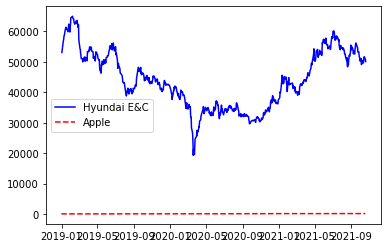

In [4]:
"""
make pandas datareader optional
otherwise can be called via fix_yahoo_finance.download(...)
"""
yf.pdr_override()
#현대건설을 가져오자
hec = pdr.get_data_yahoo(tickers = "000720.KS", start = "2019-01-01")
aapl = pdr.get_data_yahoo(tickers = "AAPL", start = "2019-01-01")

import matplotlib.pyplot as plt

plt.plot(hec.index, hec.Close, 'b', label = "Hyundai E&C")
plt.plot(aapl.index, aapl.Close, 'r--', label = "Apple")
plt.legend(loc = 'best')
plt.show()

In [5]:
print(hec.shape)
print(hec.head(5))

(690, 6)
               Open     High      Low    Close     Adj Close   Volume
Date                                                                 
2019-01-02  56500.0  56700.0  53000.0  53100.0  51485.261719   827314
2019-01-03  53300.0  55600.0  52200.0  53900.0  52260.933594  1077420
2019-01-04  53900.0  55300.0  52900.0  55000.0  53327.484375   651900
2019-01-07  56500.0  57100.0  55800.0  57000.0  55266.664062   739807
2019-01-08  57500.0  58800.0  56300.0  57300.0  55557.542969  1074658


In [6]:
"""막간을 이용해서 말하면, 이렇게 파이썬은 할당할 경우에 같은 메모리주소를 바라보기 때문에 copy로 해줘야 한다"""
hec2 = hec.copy()
print(id(hec))
print(id(hec2))

hec_test = hec
print(id(hec_test))
print(id(hec))

2051989229328
2051989225680
2051989229328
2051989229328


In [7]:
hec[(hec['Open']<57800) & (hec["Close"]>57800)]

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-06-28,56500.0,58300.0,56000.0,58200.0,58200.0,2009990
2021-07-16,57300.0,58700.0,57000.0,58400.0,58400.0,586315


In [130]:
#내가 물린 곳을 찾자!
hec[(hec['Open']<57800) & (hec["Close"]>57800)]

"""내가 물리지 않은 포인트들은 0으로 할당한다
조건에 맞는 값들을 변경할 때 좋은 문법인 것 같다.
파이썬에서도 loc을 사용하는 것을 권장하고 있다."""
hec2.loc[(hec2['Open']>57800)|(hec2['Close']<57800), 'Close']= None

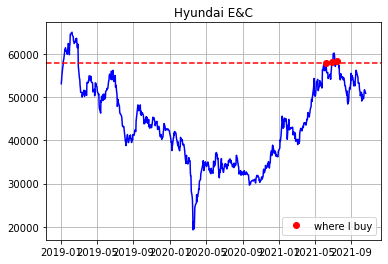

In [138]:
#현대건설 내가 어디에 물려있는지 보자
plt.figure()
plt.plot(hec.index, hec['Close'], 'b' )
plt.plot(hec2.index, hec2.Close, 'ro', label = "where I buy")
plt.legend(loc = 'lower right')
plt.grid(True)
plt.title('Hyundai E&C')
plt.axhline(y = 57800, color = "r", ls = '--')
plt.show()

### 3.4.2 일간 변동률로 주가 비교

이 방식을 이용하면 가격이 다른 두 주가의 수익률을 비교할 수 있다고 한다. 약간 스케일링 같은 느낌인듯  
$R_t(오늘 변동률) = (R_t - R_{t-1})/R_{t-1}  $

In [8]:
hec['Close']

Date
2019-01-02    53100.0
2019-01-03    53900.0
2019-01-04    55000.0
2019-01-07    57000.0
2019-01-08    57300.0
               ...   
2021-10-14    51200.0
2021-10-15    51700.0
2021-10-18    51100.0
2021-10-19    50900.0
2021-10-20    50100.0
Name: Close, Length: 690, dtype: float64

In [9]:
type(hec['Close'])

pandas.core.series.Series

shift라는 함수를 사용하여 lag를 구한다

In [10]:
hec['Close'].shift(1)

Date
2019-01-02        NaN
2019-01-03    53100.0
2019-01-04    53900.0
2019-01-07    55000.0
2019-01-08    57000.0
               ...   
2021-10-14    50200.0
2021-10-15    51200.0
2021-10-18    51700.0
2021-10-19    51100.0
2021-10-20    50900.0
Name: Close, Length: 690, dtype: float64

In [29]:
"""이제 일간 변동률을 구할 수 있다."""

hec_dpc = ((hec['Close']-hec['Close'].shift(1))/hec['Close'].shift(1))*100
hec_dpc.head(5)

Date
2019-01-02         NaN
2019-01-03    1.506591
2019-01-04    2.040816
2019-01-07    3.636364
2019-01-08    0.526316
Name: Close, dtype: float64

In [30]:
#NaN인 일간 변동률을 고쳐주자
hec_dpc.loc[hec_dpc.isna()] = 0
hec_dpc.head(5)

Date
2019-01-02    0.000000
2019-01-03    1.506591
2019-01-04    2.040816
2019-01-07    3.636364
2019-01-08    0.526316
Name: Close, dtype: float64

### 3.4.3 주가 일간 변동률 히스토그램

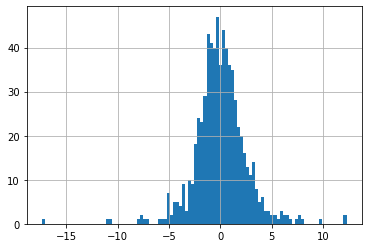

In [31]:
import matplotlib.pyplot as plt

#주가 일간 변동률 생성
hec_dpc = ((hec['Close']-hec['Close'].shift(1))/hec['Close'].shift(1))*100
hec_dpc.loc[hec_dpc.isna()] = 0

#plot 그리기
plt.figure()
plt.hist(hec_dpc, bins = 100)
plt.grid(True)
plt.show()

> 사실 0에서 높은 첨도를 보이는 분포를 보이는 이 주가 변동률은, 그만큼 변동성이 크지 않다는 것을 의미함.  
> -15 까지 x의 lim이 존재하는 것을 보니 주가가 급락한 경우가 있었던 것 같다.

In [32]:
hec_dpc.describe()

count    690.000000
mean       0.023340
std        2.514462
min      -17.344754
25%       -1.227152
50%        0.000000
75%        1.283009
max       12.276215
Name: Close, dtype: float64

그래도 평균 주가 변동률은 양의 방향이다. 중앙값은 0인걸보니 2019년부터의 주가 변동은 크지 않은 것으로 보인다.

### 3.4.4 일간 변동률 누적합

일간 변동률이기 때문에 전체적인 변동률을 비교해보려면, 일간 변동률의 누적합을 구해야 한다.

In [33]:
hec_dpc_cum = hec_dpc.cumsum()
hec_dpc_cum

Date
2019-01-02     0.000000
2019-01-03     1.506591
2019-01-04     3.547408
2019-01-07     7.183771
2019-01-08     7.710087
                ...    
2021-10-14    18.251909
2021-10-15    19.228472
2021-10-18    18.067930
2021-10-19    17.676541
2021-10-20    16.104831
Name: Close, Length: 690, dtype: float64

#### 두 종목의 일간 변동률 누적합을 비교해보자

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


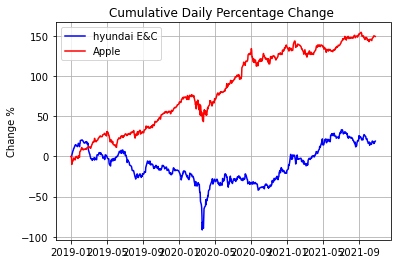

In [9]:
from pandas_datareader import data as pdr
import yfinance as yf

yf.pdr_override()

#현대건설의 누적 일간 변동률
hec = pdr.get_data_yahoo(tickers = "000720.KS", start = "2019-01-01")
hec_dpc = ((hec['Close']-hec['Close'].shift(1))/hec['Close'].shift(1))*100
hec_dpc.loc[hec_dpc.isna()] = 0
hec_dpc_cum = hec_dpc.cumsum()

#애플의 누적 일간 변동률
aapl = pdr.get_data_yahoo(tickers = "AAPL", start = "2019-01-01")
aapl_dpc = ((aapl['Close']-aapl['Close'].shift(1))/aapl['Close'].shift(1))*100
aapl_dpc.loc[aapl_dpc.isna()] = 0
aapl_dpc_cum = aapl_dpc.cumsum()

#차트로 구하기
import matplotlib.pyplot as plt
plt.figure()
plt.plot(hec.index, hec_dpc_cum, 'b', label = "hyundai E&C")
plt.plot(aapl.index, aapl_dpc_cum, 'r', label = "Apple")
plt.title('Cumulative Daily Percentage Change ')
plt.ylabel("Change %")
plt.grid(True)
plt.legend(loc = 'best')
plt.show()


In [8]:
print(hec['Close'][0])
print(hec['Close'][-1])

53100.0
51600.0


> 개인적인 사견이지만,,, 이렇게 수익률을 구할 수 없는거 아닌가? 싶다. 위처럼 관측 시작 종가가 53100원이고 관측 종료 종가가 51600원인데도 누적 일간 변동률은 양수가 나온다.

## 3.5 최대 손실 낙폭

MDD(Maximum DrawDown)은 특정 기간에 발생한 최고점에서 최저점까지의 가장 큰 손실!  
이 수치를 낮추는 것이 가장 중요하다.

$MDD = (최저점 - 최고점)/최저점$

### 3.5.1 KOSPI의 MDD

### 3.5.2 서브프라임 당시의 MDD

```시리즈.rolling(윈도우크기, min_periods = 1)[.집계함수()]```  : 시리즈에서 원하는 개수만큼 뽑아내서 집계함수에 대한 연산을 실시한다

[*********************100%***********************]  1 of 1 completed


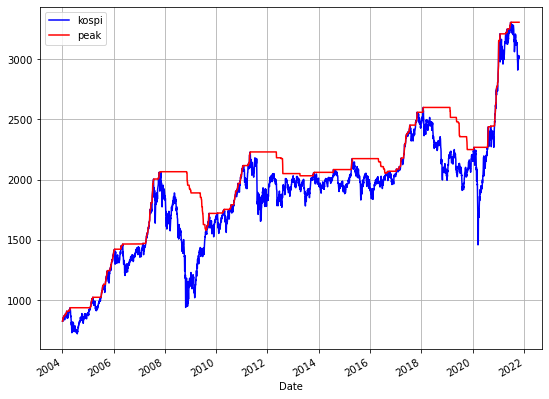

In [30]:
from pandas_datareader import data as pdr
import yfinance as yf
yf.pdr_override()
import matplotlib.pyplot as plt

#KOSPI데이터를 불러온다.
kospi = pdr.get_data_yahoo("^ks11", '2004-01-04')

#rolling을 통해 최대 손실 낙폭을 구한다.
window = 252 

#1년 동안의 최대값을 구해주는듯
peak = kospi['Adj Close'].rolling(window = window, min_periods = 1).max()

#이해를 돕기 위해 그림을 그려보자
plt.figure(figsize = (9,7))
kospi['Adj Close'].plot(c = 'blue', label = 'kospi', legend = True, grid = True)
peak.plot(c = 'red', label = 'peak', legend = True, grid = True)
plt.show()

#drawdown은 최고치대비 현재 KOSPI종가가 얼마나 하락했는지를 구해준다
drawdown = (kospi['Adj Close']-peak)/peak

#이렇게 각 시점의 종가가 최고치대비 얼마나 떨어졌는가의 1년치 최저점을 구하면 그게 MDD가 된다.
max_dd = drawdown.rolling(window = window, min_periods = 1).min()

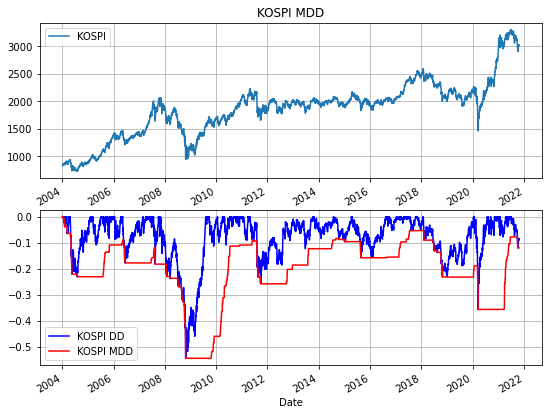

In [21]:
plt.figure(figsize = (9,7))
plt.subplot(2,1,1) #2행 1열의 공간 중 1행에 그린다.
#온전한 코스피의 값을 그려준다.
kospi['Adj Close'].plot(label = 'KOSPI', title = 'KOSPI MDD', grid = True, legend = True)

plt.subplot(2,1,2)
drawdown.plot(c = 'blue', label = 'KOSPI DD', grid = True, legend = True)
max_dd.plot(c = 'red', label = 'KOSPI MDD', grid = True, legend = True)

plt.show()

> 저 포인트들의 뜻은 1년치 최고점에 비해 몇 %하락했는지를 의미한다.   
> 서브프라임때를 보면, 거의 50% 가까이 떨어졌는데, 이는 그 당시의 종가가 1년치 최고치에 비해 거의 반토막이 났다는 의미이다..  
> MDD는 1년치 최저가이기 때문에 저 최저가는 꽤나 오랜시간 유지가 된다.

In [31]:
#정확한 MDD는 함수로 구할 수 있다고 한다.
max_dd.min()

-0.5453665130144085

In [33]:
#MDD를 기록한 날짜는 언제일까?
max_dd[max_dd == max_dd.min()]

Date
2008-10-24   -0.545367
2008-10-27   -0.545367
2008-10-28   -0.545367
2008-10-29   -0.545367
2008-10-30   -0.545367
                ...   
2009-10-16   -0.545367
2009-10-19   -0.545367
2009-10-20   -0.545367
2009-10-21   -0.545367
2009-10-22   -0.545367
Name: Adj Close, Length: 252, dtype: float64

## 3.6 회귀분석과 상관관계

### 3.6.1 KOSPI와 다우존스 지수 비교

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


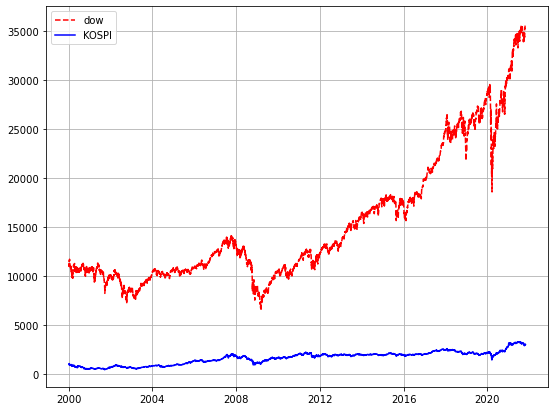

In [1]:
from pandas_datareader import data as pdr
import yfinance as yf
yf.pdr_override()
import matplotlib.pyplot as plt

kospi = pdr.get_data_yahoo("^KS11", '2000-01-04')
dow = pdr.get_data_yahoo("^DJI", '2000-01-04')

"""단순비교를 진행해봄"""
plt.figure(figsize = (9,7))
plt.plot(dow.index, dow['Close'], 'r--', label = 'dow')
plt.plot(kospi.index, kospi['Close'], 'b-', label = 'KOSPI')
plt.grid(True);plt.legend(loc = 'best'); plt.show()

> 기준이 달라서 한눈에 비교하기 어렵다.

### 3.6.2 지수화 하여 비교

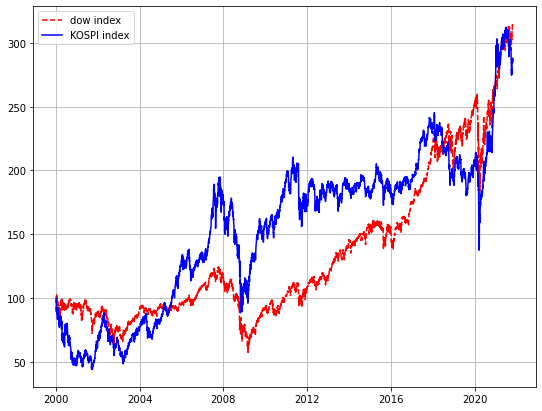

In [2]:
#관측 시작의 값에 비해 얼마나 달라졌는지를 비교하자.
d = dow["Close"]/dow['Close'][0] * 100
k = kospi["Close"]/kospi['Close'][0] * 100

"""지수화하여 비교를 진행해봄"""
plt.figure(figsize = (9,7))
plt.plot(dow.index, d, 'r--', label = 'dow index')
plt.plot(kospi.index, k, 'b-', label = 'KOSPI index')
plt.grid(True);plt.legend(loc = 'best'); plt.show()

### 3.6.3 산점도 분석

의도는 x를 코스피, y를 다우존스지수로 하여 얼마나 상관관계를 지니는지 알아보려고 하는 것 같다. 

In [15]:
print(f"다우의 길이 : {len(dow)} \n코스피의 길이: {len(kospi)}")

다우의 길이 : 5491 
코스피의 길이: 5376


In [31]:
#여러가지 방식으로 붙이는 게 있을 것 같다.
"""1) join으로 붙이기
이렇게 붙이면 열 인덱스 기준으로 붙여준다.
"""
dow.join(kospi['Close'],rsuffix = "_kospi" , how = 'outer')

,Open,High,Low,Close,Adj Close,Volume,Close_kospi
Date,,,,,,,
2000-01-03,11501.849609,11522.009766,11305.690430,11357.509766,11357.509766,169750000.0,NaN
2000-01-04,11349.750000,11350.059570,10986.450195,10997.929688,10997.929688,178420000.0,1059.040039
2000-01-05,10989.370117,11215.099609,10938.669922,11122.650391,11122.650391,203190000.0,986.309998
2000-01-06,11113.370117,11313.450195,11098.450195,11253.259766,11253.259766,176550000.0,960.789978
2000-01-07,11247.059570,11528.139648,11239.919922,11522.559570,11522.559570,184900000.0,948.650024
...,...,...,...,...,...,...,...
2021-10-21,35520.320312,35612.359375,35442.531250,35603.078125,35603.078125,298390000.0,3007.330078
2021-10-22,35607.718750,35765.019531,35533.949219,35677.019531,35677.019531,346290000.0,3006.159912
2021-10-25,35692.621094,35787.039062,35629.371094,35741.148438,35741.148438,267220000.0,3020.540039


In [35]:
import pandas as pd
df = pd.concat([dow['Close'], kospi['Close']], axis = 1, 
          #이렇게 keys를 걸면 이름도 바꿔준다!! 너무 좋음
          keys = ['dow_close', 'kospi_close'])
df.head(5)

,dow_close,kospi_close
Date,,
2000-01-03,11357.509766,NaN
2000-01-04,10997.929688,1059.040039
2000-01-05,11122.650391,986.309998
2000-01-06,11253.259766,960.789978
2000-01-07,11522.559570,948.650024


> NaN을 처리해줘야 한다.

na 처리 방법은(간편한) 두가지다  
```df.dropna()``` 혹은 ```df.fillna```

In [43]:
"""
dropna를 통하게 되면 NA를 가진 행은 모두 삭제된다.
"""
df.dropna()

,dow_close,kospi_close
Date,,
2000-01-04,10997.929688,1059.040039
2000-01-05,11122.650391,986.309998
2000-01-06,11253.259766,960.789978
2000-01-07,11522.559570,948.650024
2000-01-10,11572.200195,987.239990
...,...,...
2021-10-21,35603.078125,3007.330078
2021-10-22,35677.019531,3006.159912
2021-10-25,35741.148438,3020.540039


In [62]:
"""
method : {'backfill', 'bfill', 'pad', 'ffill', None}, default None
    Method to use for filling holes in reindexed Series
    pad / ffill: propagate last valid observation forward to next valid
    backfill / bfill: use next valid observation to fill gap.
"""

"""backfill을 사용하면 이전의 값으로 채워지게 된다고 한다. 
na interpolation과 같은 기법을 사용할 수도 있지만, 주식 시장은 장이 열리지 않는 경우 가장 최근에 장이 종료됐을때의 값을
가져오는게 맞다고 본다.
"""
#아래 코드는 하나라도 null이 있는 애들 추출
df_test = df.loc[df.isna().iloc[:,0]|df.isna().iloc[:,1]]
df_test.head(5)

,dow_close,kospi_close
Date,,
2000-01-03,11357.509766,NaN
2000-01-17,NaN,983.270020
2000-02-04,10963.799805,NaN
2000-02-21,NaN,845.320007
2000-03-01,10137.929688,NaN


In [64]:
#이렇게 전날의 데이터로 채워주는게 맞는 것 같다!
df_test.fillna(method = 'ffill')

,dow_close,kospi_close
Date,,
2000-01-03,11357.509766,NaN
2000-01-17,11357.509766,983.270020
2000-02-04,10963.799805,983.270020
2000-02-21,10963.799805,845.320007
2000-03-01,10137.929688,845.320007
...,...,...
2021-09-20,33970.468750,3203.330078
2021-09-21,33919.839844,3203.330078
2021-09-22,34258.320312,3203.330078


In [65]:
df = df.fillna(method = 'ffill')
df = df.fillna(method = 'bfill')
df.head(5)

,dow_close,kospi_close
Date,,
2000-01-03,11357.509766,1059.040039
2000-01-04,10997.929688,1059.040039
2000-01-05,11122.650391,986.309998
2000-01-06,11253.259766,960.789978
2000-01-07,11522.559570,948.650024


> 깔끔하게 제거됐음을 파악할 수 있다.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


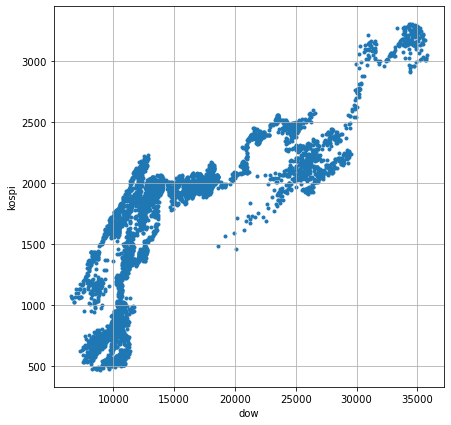

In [71]:
#scatter plot을 그려보자
from pandas_datareader import data as pdr
import yfinance as yf
yf.pdr_override()
import matplotlib.pyplot as plt

#데이터 불러오기
kospi = pdr.get_data_yahoo("^KS11", '2000-01-04')
dow = pdr.get_data_yahoo("^DJI", '2000-01-04')

#데이터 붙이기
df = pd.concat([dow['Close'], kospi['Close']], axis = 1, keys = ['dow_close', 'kospi_close'])

#na제거
df = df.fillna(method = 'ffill')
df = df.fillna(method = 'bfill')

#산점도 그리기
import matplotlib.pyplot as plt
plt.figure(figsize = (7,7))
plt.scatter(df['dow_close'], df['kospi_close'],marker='.')
plt.xlabel("dow")
plt.ylabel('kospi')
plt.grid(True)
plt.show()

> 전반적으로 우상향하는 그래프를 보여준다.

### 3.6.4 선형회귀분석

1) scipy로 구하기

In [89]:
from scipy import stats

#회귀식 진행
reg1 = stats.linregress(x = df['dow_close'], y = df['kospi_close'])
reg1

LinregressResult(slope=0.07826634900452926, intercept=439.89351438318886, rvalue=0.8125639604256654, pvalue=0.0, stderr=0.0007466427232334702)

2) scikit learn으로 구하기

In [93]:
from sklearn.linear_model import LinearRegression
reg2 = LinearRegression()
reg2.fit(df['dow_close'].values.reshape(-1,1),df['kospi_close'].values.reshape(-1,1))
reg2

LinearRegression()

3) statsmodel로 구하기

In [100]:
import statsmodels.api as sm

x = sm.add_constant(df['dow_close'])
reg3 = sm.OLS(df['kospi_close'], x)
reg3_result = reg3.fit()

In [109]:
print(reg3_result.summary())

                            OLS Regression Results                            
Dep. Variable:            kospi_close   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                 1.099e+04
Date:                Wed, 27 Oct 2021   Prob (F-statistic):               0.00
Time:                        23:59:35   Log-Likelihood:                -41602.
No. Observations:                5656   AIC:                         8.321e+04
Df Residuals:                    5654   BIC:                         8.322e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        439.8935     12.529     35.111      0.0

In [113]:
print(reg3_result.summary2())


                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.660     
Dependent Variable: kospi_close      AIC:                83207.1156
Date:               2021-10-28 00:07 BIC:                83220.3965
No. Observations:   5656             Log-Likelihood:     -41602.   
Df Model:           1                F-statistic:        1.099e+04 
Df Residuals:       5654             Prob (F-statistic): 0.00      
R-squared:          0.660            Scale:              1.4335e+05
--------------------------------------------------------------------
             Coef.    Std.Err.     t      P>|t|    [0.025    0.975] 
--------------------------------------------------------------------
const       439.8935   12.5286   35.1111  0.0000  415.3326  464.4544
dow_close     0.0783    0.0007  104.8244  0.0000    0.0768    0.0797
-------------------------------------------------------------------
Omnibus:             2030.641       Durbin-Watson:          0

<bound method RegressionResults.conf_int of <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x0000021609CB0220>>

In [117]:
reg3_result.params

439.89351438318977

## 3.7 상관계수에 따른 리스크 완화

### 3.7.1 상관계수 산출

In [111]:
df.corr()

,dow_close,kospi_close
dow_close,1.000000,0.812564
kospi_close,0.812564,1.000000


In [112]:
df['dow_close'].corr(df['kospi_close'])

0.8125639604256655

### 3.7.2 미국 국채와 코스피의 회귀분석

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


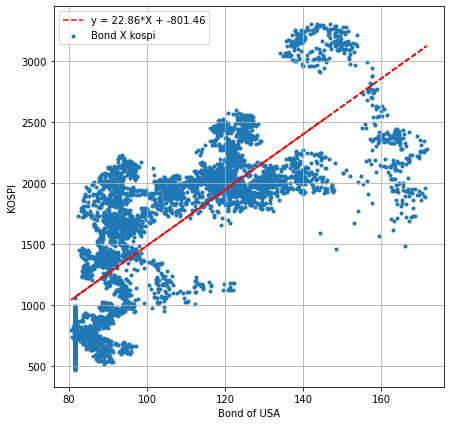

In [131]:
#scatter plot을 그려보자
from pandas_datareader import data as pdr
import yfinance as yf
yf.pdr_override()
import matplotlib.pyplot as plt

#데이터 불러오기
kospi = pdr.get_data_yahoo("^KS11", '2000-01-04')
bond = pdr.get_data_yahoo("TLT", '2000-01-04')

#데이터 붙이기
df = pd.concat([bond['Close'], kospi['Close']], axis = 1, keys = ['bond_close', 'kospi_close'])

#na제거
df = df.fillna(method = 'ffill')
df = df.fillna(method = 'bfill')

#회귀식 산출
import statsmodels.api as sm
x = sm.add_constant(df['bond_close'])
reg3 = sm.OLS(df['kospi_close'], x)
reg3_fit = reg3.fit()
reg_equation = reg3_fit.predict(x)
reg_name = f"y = {reg3_fit.params[1]:.2f}*X + {reg3_fit.params[0]:.2f}"

#산점도 그리기
import matplotlib.pyplot as plt
plt.figure(figsize = (7,7))
plt.scatter(df['bond_close'], df['kospi_close'],marker='.')
plt.plot(df['bond_close'], reg_equation, 'r--')
plt.legend([reg_name, "Bond X kospi"])
plt.xlabel("Bond of USA")
plt.ylabel('KOSPI')
plt.grid(True)
plt.show()